# **10x Visium colon metabolic crosstalk robustness analysis**

In [113]:
import harreman
import os
import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from itertools import product
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

## Visium colon dataset

In [2]:
BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Visium_colon"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

In [3]:
adata = harreman.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_Harreman_unrolled.h5ad'))

### Pairwise correlation (number of neighbors)

In [4]:
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

In [5]:
def metabolite_pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors):

    harreman.pp.extract_interaction_db(adata, species='mouse', database='both')
    
    harreman.tl.compute_knn_graph(adata, 
                           compute_neighbors_on_key="spatial_unrolled", 
                           n_neighbors=n_neighbors,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.tl.compute_gene_pairs(adata, ct_specific = False)

    harreman.tl.compute_cell_communication(adata, model='danb', M = 1000, test = "both", layer_key_p_test='counts', layer_key_np_test='log_norm')

    harreman.tl.select_significant_interactions(adata, test = "non-parametric", threshold = 0.05)
    
    cell_com_df_gp = adata.uns['ccc_results']['cell_com_df_gp']
    cell_com_df_m = adata.uns['ccc_results']['cell_com_df_m']

    return cell_com_df_gp, cell_com_df_m

In [6]:
def compute_significant_event_jaccard(dictionary):
    
    jaccard_sim_matrix = np.zeros((len(dictionary.keys()), len(dictionary.keys())))
    for i in range(len(dictionary.keys())):
        for j in range(len(dictionary.keys())):
            key_i = list(dictionary.keys())[i]
            key_j = list(dictionary.keys())[j]
            a = dictionary[key_i]
            b = dictionary[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=dictionary.keys(), columns=dictionary.keys())
    
    return jaccard_sim_matrix_df

In [7]:
def compute_event_correlation(dictionary):
    
    corr_df = pd.concat(dictionary, axis=1, join="inner").corr()
    
    return corr_df

In [8]:
def to_str(x):
    if isinstance(x, list):
        return "_".join(map(str, x))
    return str(x)

In [9]:
significant_gene_pairs_dict = {}
significant_metabolites_dict = {}
gene_pairs_z_scores_dict = {}
metabolites_z_scores_dict = {}
for n_neighbors in n_neighbors_values:
    print(n_neighbors)
    cell_com_df_gp, cell_com_df_m = metabolite_pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors)
    cell_com_df_gp = cell_com_df_gp.copy()
    cell_com_df_m = cell_com_df_m.copy()
    cell_com_df_gp.index = (cell_com_df_gp["Gene 1"].apply(to_str) + "_" + cell_com_df_gp["Gene 2"].apply(to_str))
    cell_com_df_m = cell_com_df_m.set_index('Metabolite')
    significant_gene_pairs_dict[n_neighbors] = cell_com_df_gp[cell_com_df_gp['selected']].index.tolist()
    significant_metabolites_dict[n_neighbors] = cell_com_df_m[cell_com_df_m['selected']].index.tolist()
    gene_pairs_z_scores_dict[n_neighbors] = cell_com_df_gp['Z']
    metabolites_z_scores_dict[n_neighbors] = cell_com_df_m['Z']

5


Permutation test: 100%|██████████| 1000/1000 [00:37<00:00, 26.60it/s]


10


Permutation test: 100%|██████████| 1000/1000 [00:41<00:00, 24.20it/s]


15


...

Permutation test: 100%|██████████| 1000/1000 [00:59<00:00, 16.68it/s]


45


Permutation test: 100%|██████████| 1000/1000 [01:02<00:00, 16.00it/s]


50


Permutation test: 100%|██████████| 1000/1000 [01:05<00:00, 15.26it/s]


In [10]:
gp_jaccard_sim_matrix_df = compute_significant_event_jaccard(significant_gene_pairs_dict)
m_jaccard_sim_matrix_df = compute_significant_event_jaccard(significant_metabolites_dict)

gp_cor_matrix_df = compute_event_correlation(gene_pairs_z_scores_dict)
m_cor_matrix_df = compute_event_correlation(metabolites_z_scores_dict)

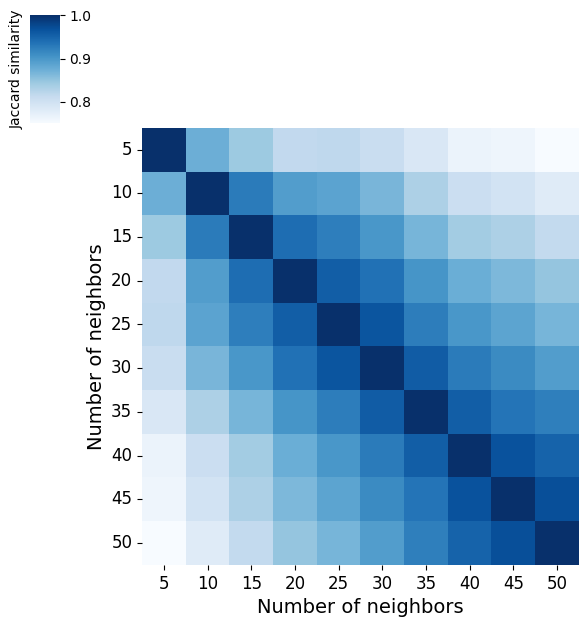

In [14]:
cm = sns.clustermap(data=gp_jaccard_sim_matrix_df, row_cluster=False, col_cluster=False, cmap='Blues', figsize=(6,6), vmin=0.75)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Jaccard similarity')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'gp_n_neighbors_jaccard_cluster_map.svg'))

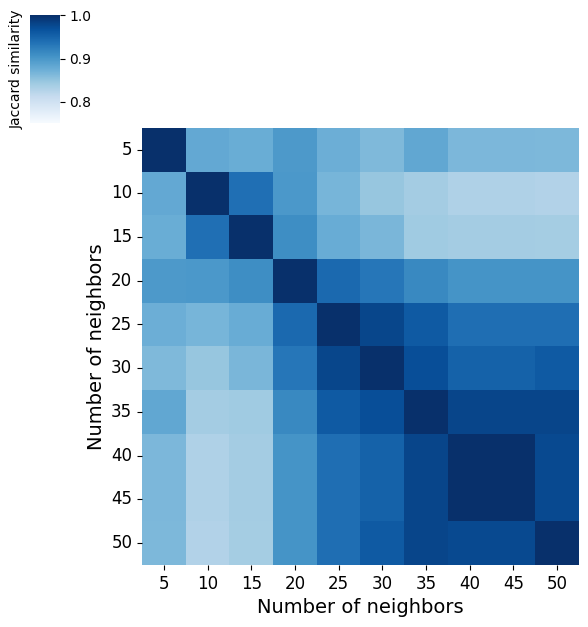

In [15]:
cm = sns.clustermap(data=m_jaccard_sim_matrix_df, row_cluster=False, col_cluster=False, cmap='Blues', figsize=(6,6), vmin=0.75)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Jaccard similarity')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'metab_n_neighbors_jaccard_cluster_map.svg'))

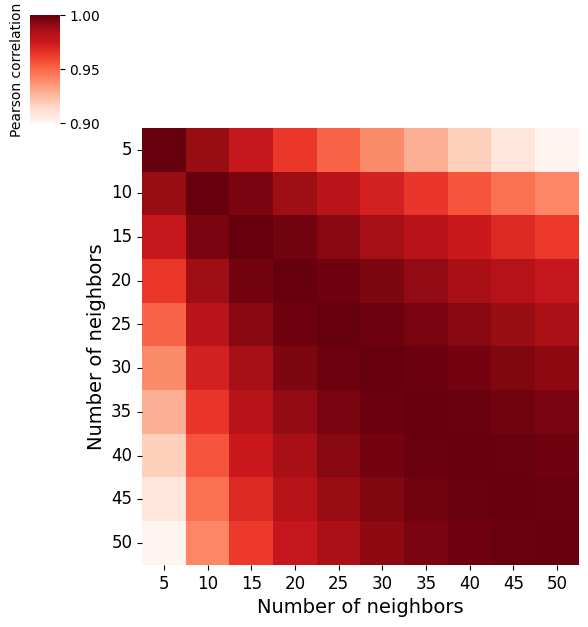

In [20]:
cm = sns.clustermap(data=gp_cor_matrix_df, row_cluster=False, col_cluster=False, cmap='Reds', figsize=(6,6), vmin=0.9)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Pearson correlation')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'gp_n_neighbors_pearson_cluster_map.svg'))

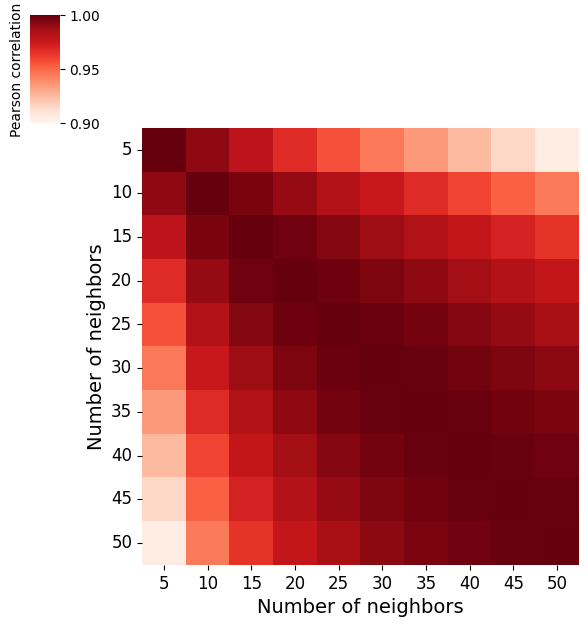

In [21]:
cm = sns.clustermap(data=m_cor_matrix_df, row_cluster=False, col_cluster=False, cmap='Reds', figsize=(6,6), vmin=0.9)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Pearson correlation')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'metab_n_neighbors_pearson_cluster_map.svg'))

### FDR CDF plots

In [15]:
def empirical_cdf(x):
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y

In [56]:
def visualize_results(x1_sorted, x2_sorted, y1, y2, title):
    plt.figure(figsize=(5, 5))
    plt.step(x1_sorted, y1, where="post", label='Parametric test', linewidth=2, color='#252525')
    plt.step(x2_sorted, y2, where="post", label='Non-parametric test', linewidth=2, color='#6BAED6')
    
    plt.vlines(
        0.05,
        0,
        1,
        linestyles="dashed",
        colors="#737373",
        label="FDR = 0.05"
    )

    plt.xlabel("FDR", fontsize=14)
    plt.ylabel("Empirical CDF", fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()

#### Metabolic Hotspot

In [64]:
adata = ad.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_unrolled_adata.h5ad'))

In [65]:
sample_col = 'cond'
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep].copy()

In [66]:
harreman.tl.compute_knn_graph(adata, 
                           compute_neighbors_on_key="spatial_unrolled", 
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond',
                           verbose=True)

Computing the neighborhood graph...
Restricting graph within samples using 'cond'...


100%|██████████| 2/2 [00:00<00:00, 95.93it/s]

Computing the weights...
Finished computing the KNN graph in 0.045 seconds


In [67]:
harreman.hs.compute_local_autocorrelation(adata, layer_key="counts", model='danb', species='mouse', use_metabolic_genes=True, permutation_test=True, verbose=True)

Computing local autocorrelation...


Permutation test: 100%|██████████| 1000/1000 [00:03<00:00, 326.69it/s]

Local autocorrelation results are stored in adata.uns['gene_autocorrelation_results']
Finished computing local autocorrelation in 3.333 seconds


In [68]:
x1 = adata.uns['gene_autocorrelation_results']['Z_FDR'].dropna().values
x2 = adata.uns['gene_autocorrelation_results']['Perm_FDR'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

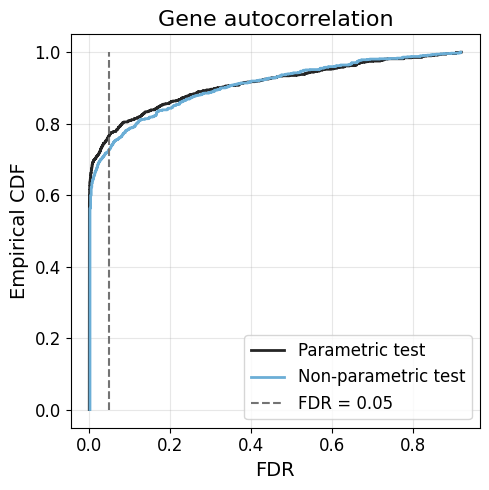

In [69]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Gene autocorrelation')
plt.savefig(f'{PLOTS_PATH}/gene_autocorrelation_FDR_CDF_plot.svg')
plt.show()

In [70]:
gene_autocorrelation_results = adata.uns['gene_autocorrelation_results']
genes = gene_autocorrelation_results.loc[gene_autocorrelation_results.Z_FDR < 0.01].sort_values('Z', ascending=False).index

In [71]:
harreman.hs.compute_local_correlation(adata, genes=genes, permutation_test=True, verbose=True, device='cpu')

Computing pair-wise local correlation on 759 features...


Permutation test: 100%|██████████| 1000/1000 [01:31<00:00, 10.98it/s]


Pair-wise local correlation results are stored in adata.uns with the following keys: ['lc_perm_pvals', 'lc_perm_pvals_sym', 'lcs', 'lc_zs', 'lc_z_pvals', 'lc_z_FDR']
Finished computing pair-wise local correlation in 91.702 seconds


In [72]:
x1 = adata.uns['lc_z_FDR'].values.flatten()
x2 = multipletests(adata.uns['lc_perm_pvals'].values.flatten(), method="fdr_bh")[1]

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

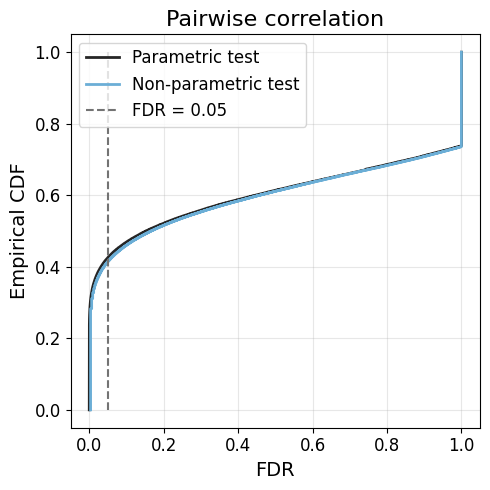

In [73]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Pairwise correlation')
plt.savefig(f'{PLOTS_PATH}/pairwise_correlation_FDR_CDF_plot.svg')
plt.show()

#### ct-agnostic Harreman

In [46]:
adata = harreman.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_Harreman_unrolled.h5ad'))

In [59]:
cell_com_df_gp = adata.uns['ccc_results']['cell_com_df_gp'].copy()
cell_com_df_m = adata.uns['ccc_results']['cell_com_df_m'].copy()

#### Gene pairs

In [60]:
x1 = cell_com_df_gp['Z_FDR'].dropna().values
x2 = cell_com_df_gp['FDR_np'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

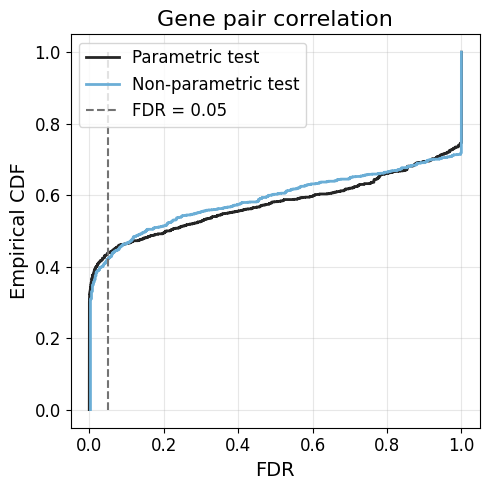

In [61]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Gene pair correlation')
plt.savefig(f'{PLOTS_PATH}/gp_correlation_FDR_CDF_plot.svg')
plt.show()

#### Metabolites

In [62]:
x1 = cell_com_df_m['Z_FDR'].dropna().values
x2 = cell_com_df_m['FDR_np'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

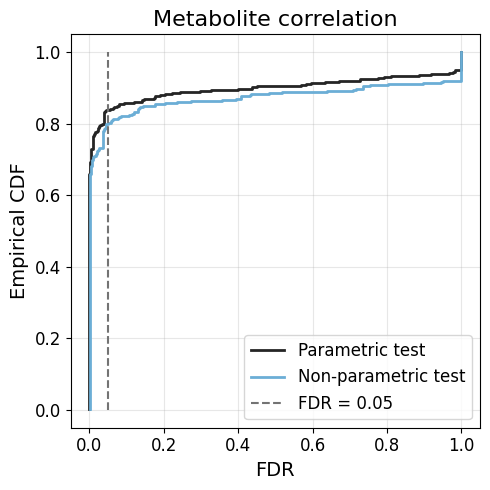

In [63]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Metabolite correlation')
plt.savefig(f'{PLOTS_PATH}/metab_correlation_FDR_CDF_plot.svg')
plt.show()

### Pairwise correlation (threshold)

In [193]:
threshold_values = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
ref_value = 1

In [194]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n):
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    
    means = np.nanmean(interacting_cell_scores_m, axis=0)
    stds = np.nanstd(interacting_cell_scores_m, axis=0)
    thresholds = means + n*stds
    interacting_cell_scores_m[interacting_cell_scores_m < thresholds] = 0
    
    interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    interacting_cell_scores_m[interacting_cell_scores_m != 0] = 1
    
    metab_scores_adata = ad.AnnData(interacting_cell_scores_m)
    metab_scores_adata.obs_names = adata.obs_names
    metab_scores_adata.var_names = adata.uns['metabolites']

    metab_scores_adata.obs['cond'] = adata.obs['cond']
    metab_scores_adata.obsm['spatial_unrolled'] = adata.obsm['spatial_unrolled']
    metab_scores_adata.obsm['spatial'] = adata.obsm['spatial']
    
    harreman.tl.compute_knn_graph(metab_scores_adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.hs.compute_local_autocorrelation(metab_scores_adata, model='bernoulli')
    
    gene_autocorrelation_results = metab_scores_adata.uns['gene_autocorrelation_results']
    metabolites = gene_autocorrelation_results.index
    
    harreman.hs.compute_local_correlation(metab_scores_adata, genes=metabolites)
        
    harreman.hs.create_modules(metab_scores_adata, min_gene_threshold=9)
    
    harreman.hs.calculate_module_scores(metab_scores_adata)
    
    return metab_scores_adata.uns['gene_modules'], metab_scores_adata.obsm['module_scores']

In [195]:
def pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref):
    
    jaccard_sim_matrix = np.zeros((len(gene_modules.keys()), len(gene_modules_ref.keys())))
    for i in range(len(gene_modules.keys())):
        for j in range(len(gene_modules_ref.keys())):
            key_i = list(gene_modules.keys())[i]
            key_j = list(gene_modules_ref.keys())[j]
            a = gene_modules[key_i]
            b = gene_modules_ref[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=gene_modules.keys(), columns=gene_modules_ref.keys())
    
    correlation_matrix = pd.DataFrame(
        [[module_scores[col1].corr(module_scores_ref[col2]) for col2 in module_scores_ref.columns] for col1 in module_scores.columns],
        index=module_scores.columns,
        columns=module_scores_ref.columns
    )
    
    similarity_matrix = (jaccard_sim_matrix_df + correlation_matrix)/2
    max_similarity = similarity_matrix.idxmax()
    
    correlation_values = [correlation_matrix.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    jaccard_values = [jaccard_sim_matrix_df.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    
    return correlation_values, jaccard_values

In [196]:
pairwise_correlation_gene_modules_dict = {}
pairwise_correlation_module_scores_dict = {}
for n in threshold_values:
    print(n)
    gene_modules, module_scores = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n)
    pairwise_correlation_gene_modules_dict[n] = gene_modules
    pairwise_correlation_module_scores_dict[n] = module_scores

0


100%|██████████| 2/2 [00:00<00:00, 101.81it/s]


100%|██████████| 10/10 [00:00<00:00, 19.18it/s]


0.5


100%|██████████| 7/7 [00:00<00:00, 18.35it/s]


...

100%|██████████| 4/4 [00:00<00:00, 22.09it/s]


4.5


100%|██████████| 3/3 [00:00<00:00, 20.86it/s]


5


100%|██████████| 2/2 [00:00<00:00, 22.99it/s]


In [197]:
correlation_values_dict = {}
jaccard_values_dict = {}
n_modules_dict = {}
for n in threshold_values:
    gene_modules = pairwise_correlation_gene_modules_dict[n]
    module_scores = pairwise_correlation_module_scores_dict[n]
    gene_modules_ref = pairwise_correlation_gene_modules_dict[ref_value]
    module_scores_ref = pairwise_correlation_module_scores_dict[ref_value]
    correlation_values, jaccard_values = pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref)
    correlation_values_dict[n] = correlation_values
    jaccard_values_dict[n] = jaccard_values
    n_modules_dict[n] = len(gene_modules.keys())

In [198]:
n_modules_df = pd.DataFrame.from_dict(n_modules_dict.items()).rename(columns={0: 'n_sd', 1: 'n_modules'})

In [199]:
jaccard_values_df = pd.concat(
    {key: pd.Series(list) for key, list in jaccard_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

correlation_values_df = pd.concat(
    {key: pd.Series(list) for key, list in correlation_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

In [200]:
jaccard_values_df["n_sd"] = jaccard_values_df["n_sd"].astype('category')
correlation_values_df["n_sd"] = correlation_values_df["n_sd"].astype('category')
n_modules_df["n_sd"] = n_modules_df["n_sd"].astype('category')

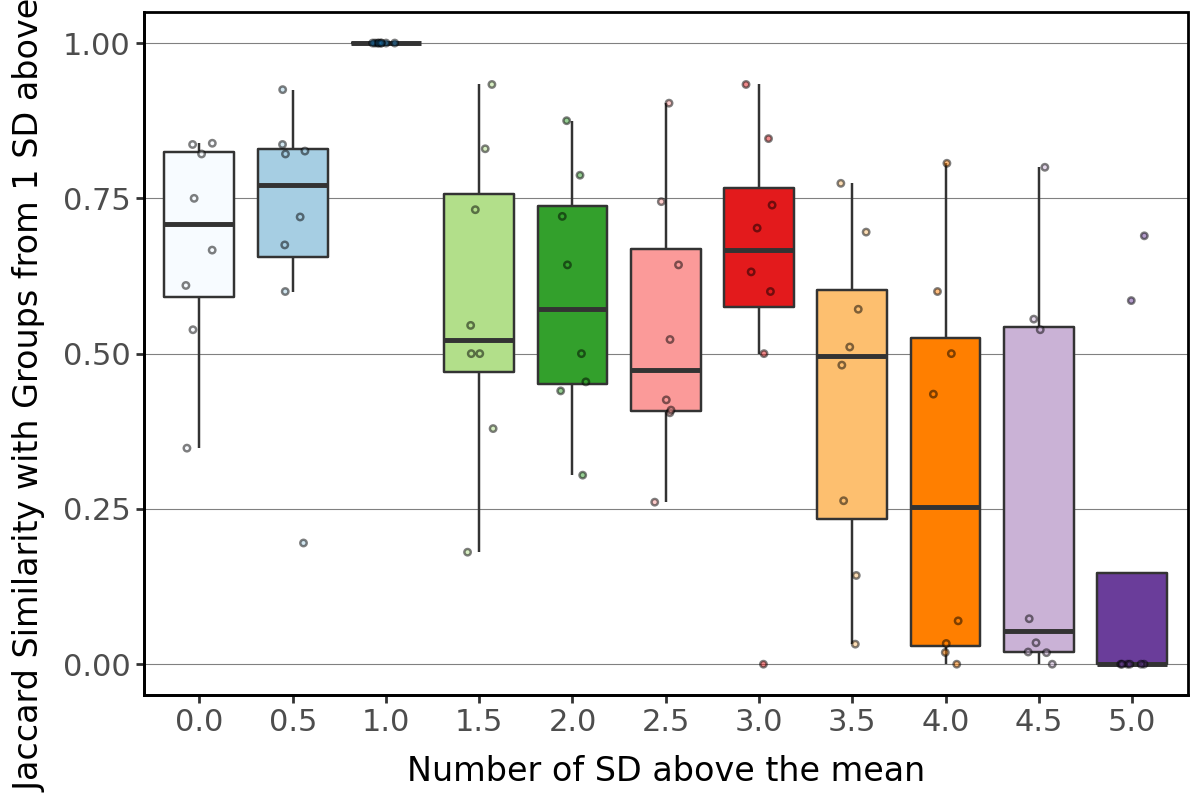

In [202]:
fig = (
ggplot(data=jaccard_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Jaccard Similarity with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_jaccard_n_sd_box_plot_unrolled.svg'), format='svg')
fig

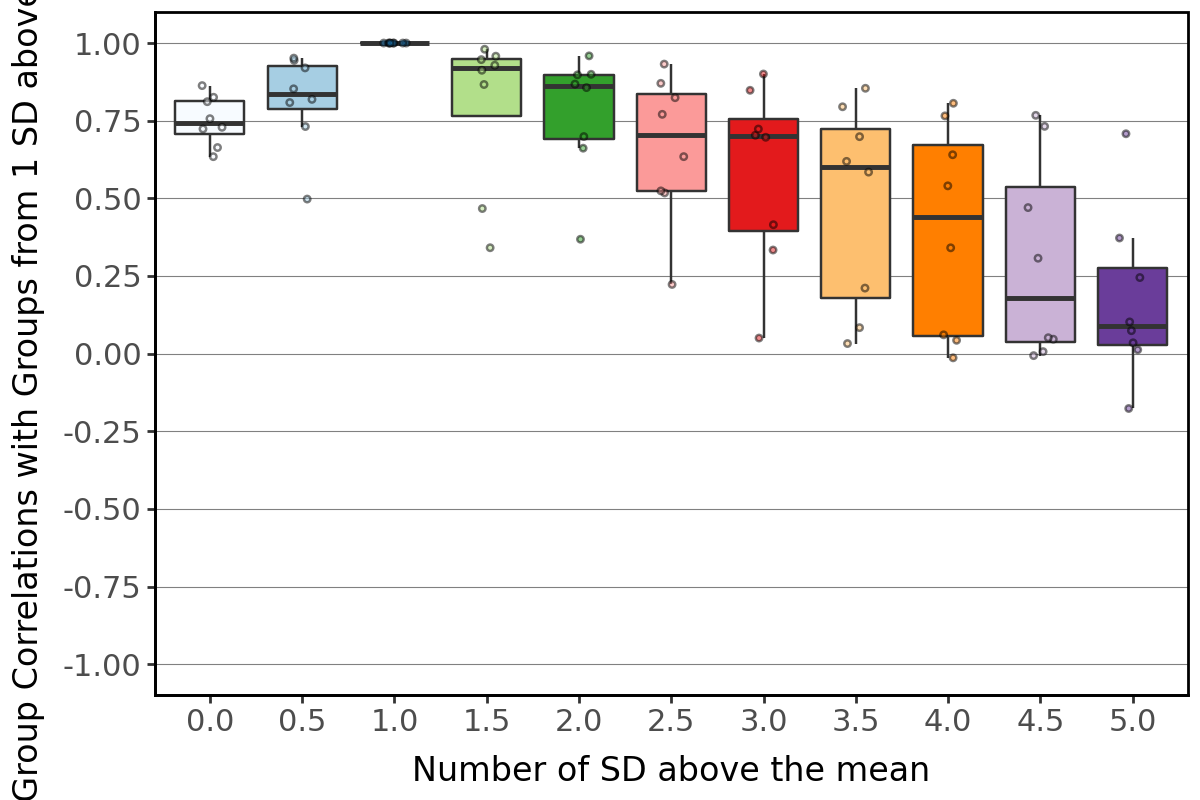

In [203]:
fig = (
ggplot(data=correlation_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Group Correlations with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(-1, 1),
        breaks=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_max_cor_n_sd_box_plot_unrolled.svg'), format='svg')
fig

### Pairwise correlation (Gaussian processes = 2 and p-value/FDR < 0.05)

In [204]:
ref_value = 'std'

In [205]:
def gmm_binarize_matrix(X, k=2, prob_threshold=0.5):
    """
    Fit a GMM per column and binarize based on component assignment.
    
    Parameters:
        X: np.array (cells x metabolites)
        k: number of Gaussian components (2)
        prob_threshold: probability threshold for assignment
    
    Returns:
        X_bin: binarized matrix
    """
    X_bin = np.zeros_like(X)

    for j in range(X.shape[1]):
        col = X[:, j].reshape(-1, 1)

        # remove NaNs
        mask = ~np.isnan(col[:, 0])
        col_valid = col[mask]

        if len(col_valid) < 10:
            continue

        gmm = GaussianMixture(n_components=k, random_state=0)
        gmm.fit(col_valid)

        # posterior probabilities
        probs = gmm.predict_proba(col_valid)

        # identify "high" component (larger mean)
        high_comp = np.argmax(gmm.means_.flatten())

        # assign
        bin_vals = (probs[:, high_comp] > prob_threshold).astype(int)

        X_bin[mask, j] = bin_vals

    return X_bin

In [206]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process='gmm'):
    
    if process not in ['gmm', 'pval', 'FDR', 'std']:
        raise ValueError('The "process" variable needs to be one of: "gmm", "pval", "FDR", or "std".')
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    # interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    
    if process == 'gmm':
        interacting_cell_scores_m = gmm_binarize_matrix(
            interacting_cell_scores_m,
            k=2,
            prob_threshold=0.5
        )
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    elif process in ['pval', 'FDR']:
        interacting_cell_pvalues_m = adata.uns['interacting_cell_results']['np']['m'][process]
        interacting_cell_scores_m = (interacting_cell_pvalues_m < 0.05).astype(int)
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    else:
        n=1
        means = np.nanmean(interacting_cell_scores_m, axis=0)
        stds = np.nanstd(interacting_cell_scores_m, axis=0)
        thresholds = means + n*stds
        interacting_cell_scores_m[interacting_cell_scores_m < thresholds] = 0
        
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        interacting_cell_scores_m[interacting_cell_scores_m != 0] = 1
        
    metab_scores_adata = ad.AnnData(interacting_cell_scores_m)
    metab_scores_adata.obs_names = adata.obs_names
    metab_scores_adata.var_names = adata.uns['metabolites']

    metab_scores_adata.obs['cond'] = adata.obs['cond']
    metab_scores_adata.obsm['spatial_unrolled'] = adata.obsm['spatial_unrolled']
    metab_scores_adata.obsm['spatial'] = adata.obsm['spatial']
    
    harreman.tl.compute_knn_graph(metab_scores_adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.hs.compute_local_autocorrelation(metab_scores_adata, model='bernoulli')
    
    gene_autocorrelation_results = metab_scores_adata.uns['gene_autocorrelation_results']
    metabolites = gene_autocorrelation_results.index
    
    harreman.hs.compute_local_correlation(metab_scores_adata, genes=metabolites)
        
    harreman.hs.create_modules(metab_scores_adata, min_gene_threshold=9)
    
    harreman.hs.calculate_module_scores(metab_scores_adata)
    
    return metab_scores_adata.uns['gene_modules'], metab_scores_adata.obsm['module_scores']

In [207]:
def pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref):
    
    jaccard_sim_matrix = np.zeros((len(gene_modules.keys()), len(gene_modules_ref.keys())))
    for i in range(len(gene_modules.keys())):
        for j in range(len(gene_modules_ref.keys())):
            key_i = list(gene_modules.keys())[i]
            key_j = list(gene_modules_ref.keys())[j]
            a = gene_modules[key_i]
            b = gene_modules_ref[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=gene_modules.keys(), columns=gene_modules_ref.keys())
    
    correlation_matrix = pd.DataFrame(
        [[module_scores[col1].corr(module_scores_ref[col2]) for col2 in module_scores_ref.columns] for col1 in module_scores.columns],
        index=module_scores.columns,
        columns=module_scores_ref.columns
    )
    
    similarity_matrix = (jaccard_sim_matrix_df + correlation_matrix)/2
    max_similarity = similarity_matrix.idxmax()
    
    correlation_values = [correlation_matrix.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    jaccard_values = [jaccard_sim_matrix_df.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    
    return correlation_values, jaccard_values

In [208]:
pairwise_correlation_gene_modules_dict = {}
pairwise_correlation_module_scores_dict = {}
for process in ['gmm', 'pval', 'FDR', 'std']:
    print(process)
    gene_modules, module_scores = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process)
    pairwise_correlation_gene_modules_dict[process] = gene_modules
    pairwise_correlation_module_scores_dict[process] = module_scores

gmm


100%|██████████| 9/9 [00:00<00:00, 17.09it/s]


pval


100%|██████████| 10/10 [00:00<00:00, 16.41it/s]


FDR


100%|██████████| 8/8 [00:00<00:00, 19.70it/s]


std


100%|██████████| 8/8 [00:00<00:00, 19.22it/s]


In [209]:
correlation_values_dict = {}
jaccard_values_dict = {}
n_modules_dict = {}
for process in ['gmm', 'pval', 'FDR']:
    gene_modules = pairwise_correlation_gene_modules_dict[process]
    module_scores = pairwise_correlation_module_scores_dict[process]
    gene_modules_ref = pairwise_correlation_gene_modules_dict[ref_value]
    module_scores_ref = pairwise_correlation_module_scores_dict[ref_value]
    correlation_values, jaccard_values = pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref)
    correlation_values_dict[process] = correlation_values
    jaccard_values_dict[process] = jaccard_values
    n_modules_dict[process] = len(gene_modules.keys())

In [210]:
n_modules_df = pd.DataFrame.from_dict(n_modules_dict.items()).rename(columns={0: 'process', 1: 'n_modules'})

In [211]:
jaccard_values_df = pd.concat(
    {key: pd.Series(list) for key, list in jaccard_values_dict.items()}, axis=1
).melt( 
    var_name="process", 
    value_name="Value"
)

correlation_values_df = pd.concat(
    {key: pd.Series(list) for key, list in correlation_values_dict.items()}, axis=1
).melt( 
    var_name="process", 
    value_name="Value"
)

In [212]:
jaccard_values_df["process"] = jaccard_values_df["process"].astype('category')
jaccard_values_df["process"] = jaccard_values_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])
correlation_values_df["process"] = correlation_values_df["process"].astype('category')
correlation_values_df["process"] = correlation_values_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])
n_modules_df["process"] = n_modules_df["process"].astype('category')
n_modules_df["process"] = n_modules_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])

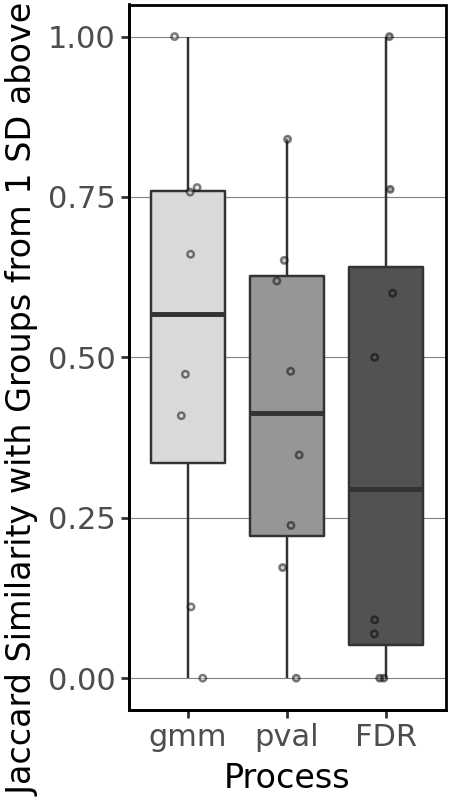

In [215]:
fig = (
ggplot(data=jaccard_values_df, mapping=aes(x="process", y="Value", fill="process")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#D9D9D9", "#969696", "#525252"])
+ xlab('Process')
+ ylab('Max. Jaccard Similarity with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(2.25, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_jaccard_processes_box_plot_unrolled.svg'), format='svg')
fig

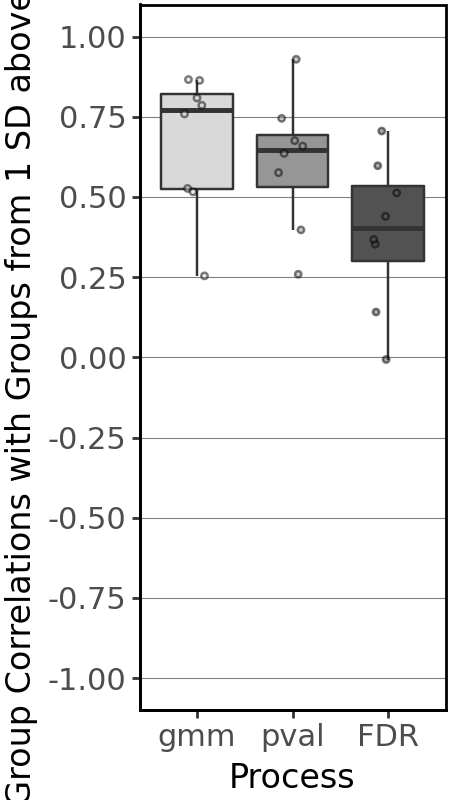

In [216]:
fig = (
ggplot(data=correlation_values_df, mapping=aes(x="process", y="Value", fill="process")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#D9D9D9", "#969696", "#525252"])
+ xlab('Process')
+ ylab('Max. Group Correlations with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(-1, 1),
        breaks=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(2.25, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_max_cor_processes_box_plot_unrolled.svg'), format='svg')
fig

### Pairwise correlation (threshold vs continuous inference)

In [217]:
threshold_values = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
ref_value = 'cont'

In [218]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n):
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    
    if n == 'cont':
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        std = interacting_cell_scores_m.std(axis=0)
        std_replaced = std.replace(0, 1)  # avoid division by zero
        interacting_cell_scores_m = (interacting_cell_scores_m - interacting_cell_scores_m.mean(axis=0)) / std_replaced
        model = 'none'
    else:
        means = np.nanmean(interacting_cell_scores_m, axis=0)
        stds = np.nanstd(interacting_cell_scores_m, axis=0)
        thresholds = means + n*stds
        interacting_cell_scores_m[interacting_cell_scores_m < thresholds] = 0
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        interacting_cell_scores_m[interacting_cell_scores_m != 0] = 1
        model = 'bernoulli'
    
    metab_scores_adata = ad.AnnData(interacting_cell_scores_m)
    metab_scores_adata.obs_names = adata.obs_names
    metab_scores_adata.var_names = adata.uns['metabolites']

    metab_scores_adata.obs['cond'] = adata.obs['cond']
    metab_scores_adata.obsm['spatial_unrolled'] = adata.obsm['spatial_unrolled']
    metab_scores_adata.obsm['spatial'] = adata.obsm['spatial']
    
    harreman.tl.compute_knn_graph(metab_scores_adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.hs.compute_local_autocorrelation(metab_scores_adata, model=model)
    
    gene_autocorrelation_results = metab_scores_adata.uns['gene_autocorrelation_results']
    metabolites = gene_autocorrelation_results.index
    
    harreman.hs.compute_local_correlation(metab_scores_adata, genes=metabolites)
        
    harreman.hs.create_modules(metab_scores_adata, min_gene_threshold=9)
    
    harreman.hs.calculate_module_scores(metab_scores_adata)
    
    return metab_scores_adata.uns['gene_modules'], metab_scores_adata.obsm['module_scores']

In [219]:
def pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref):
    
    jaccard_sim_matrix = np.zeros((len(gene_modules.keys()), len(gene_modules_ref.keys())))
    for i in range(len(gene_modules.keys())):
        for j in range(len(gene_modules_ref.keys())):
            key_i = list(gene_modules.keys())[i]
            key_j = list(gene_modules_ref.keys())[j]
            a = gene_modules[key_i]
            b = gene_modules_ref[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=gene_modules.keys(), columns=gene_modules_ref.keys())
    
    correlation_matrix = pd.DataFrame(
        [[module_scores[col1].corr(module_scores_ref[col2]) for col2 in module_scores_ref.columns] for col1 in module_scores.columns],
        index=module_scores.columns,
        columns=module_scores_ref.columns
    )
    
    similarity_matrix = (jaccard_sim_matrix_df + correlation_matrix)/2
    max_similarity = similarity_matrix.idxmax()
    
    correlation_values = [correlation_matrix.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    jaccard_values = [jaccard_sim_matrix_df.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    
    return correlation_values, jaccard_values

In [220]:
pairwise_correlation_gene_modules_dict = {}
pairwise_correlation_module_scores_dict = {}
for n in [ref_value] + threshold_values:
    print(n)
    gene_modules, module_scores = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n)
    pairwise_correlation_gene_modules_dict[n] = gene_modules
    pairwise_correlation_module_scores_dict[n] = module_scores

cont


100%|██████████| 2/2 [00:00<00:00, 113.19it/s]


100%|██████████| 10/10 [00:00<00:00, 28.43it/s]


0


100%|██████████| 10/10 [00:00<00:00, 19.30it/s]


...

100%|██████████| 4/4 [00:00<00:00, 20.41it/s]


4.5


100%|██████████| 3/3 [00:00<00:00, 24.81it/s]


5


100%|██████████| 2/2 [00:00<00:00, 27.27it/s]


In [221]:
correlation_values_dict = {}
jaccard_values_dict = {}
n_modules_dict = {}
for n in threshold_values:
    gene_modules = pairwise_correlation_gene_modules_dict[n]
    module_scores = pairwise_correlation_module_scores_dict[n]
    gene_modules_ref = pairwise_correlation_gene_modules_dict[ref_value]
    module_scores_ref = pairwise_correlation_module_scores_dict[ref_value]
    correlation_values, jaccard_values = pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref)
    correlation_values_dict[n] = correlation_values
    jaccard_values_dict[n] = jaccard_values
    n_modules_dict[n] = len(gene_modules.keys())

In [222]:
n_modules_df = pd.DataFrame.from_dict(n_modules_dict.items()).rename(columns={0: 'n_sd', 1: 'n_modules'})

In [223]:
jaccard_values_df = pd.concat(
    {key: pd.Series(list) for key, list in jaccard_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

correlation_values_df = pd.concat(
    {key: pd.Series(list) for key, list in correlation_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

In [224]:
jaccard_values_df["n_sd"] = jaccard_values_df["n_sd"].astype('category')
correlation_values_df["n_sd"] = correlation_values_df["n_sd"].astype('category')
n_modules_df["n_sd"] = n_modules_df["n_sd"].astype('category')

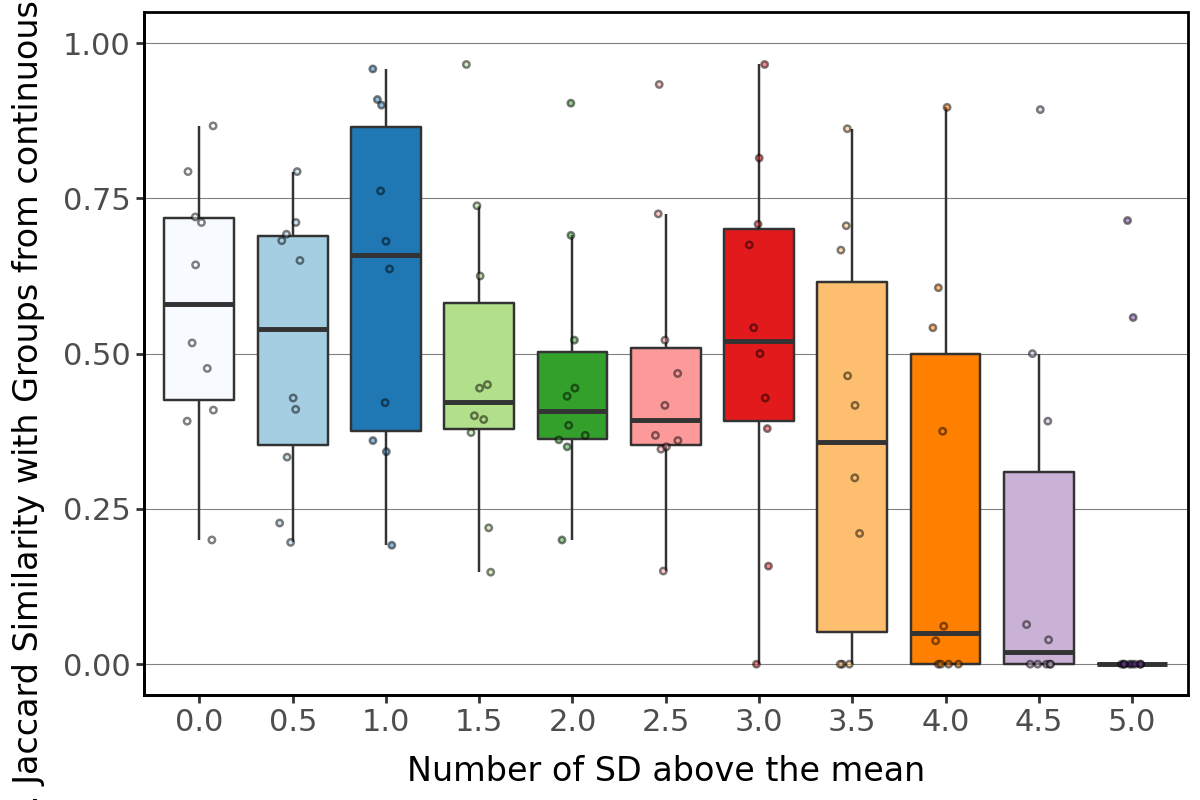

In [225]:
fig = (
ggplot(data=jaccard_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Jaccard Similarity with Groups from continuous inference')
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_jaccard_n_sd_cont_box_plot_unrolled.svg'), format='svg')
fig

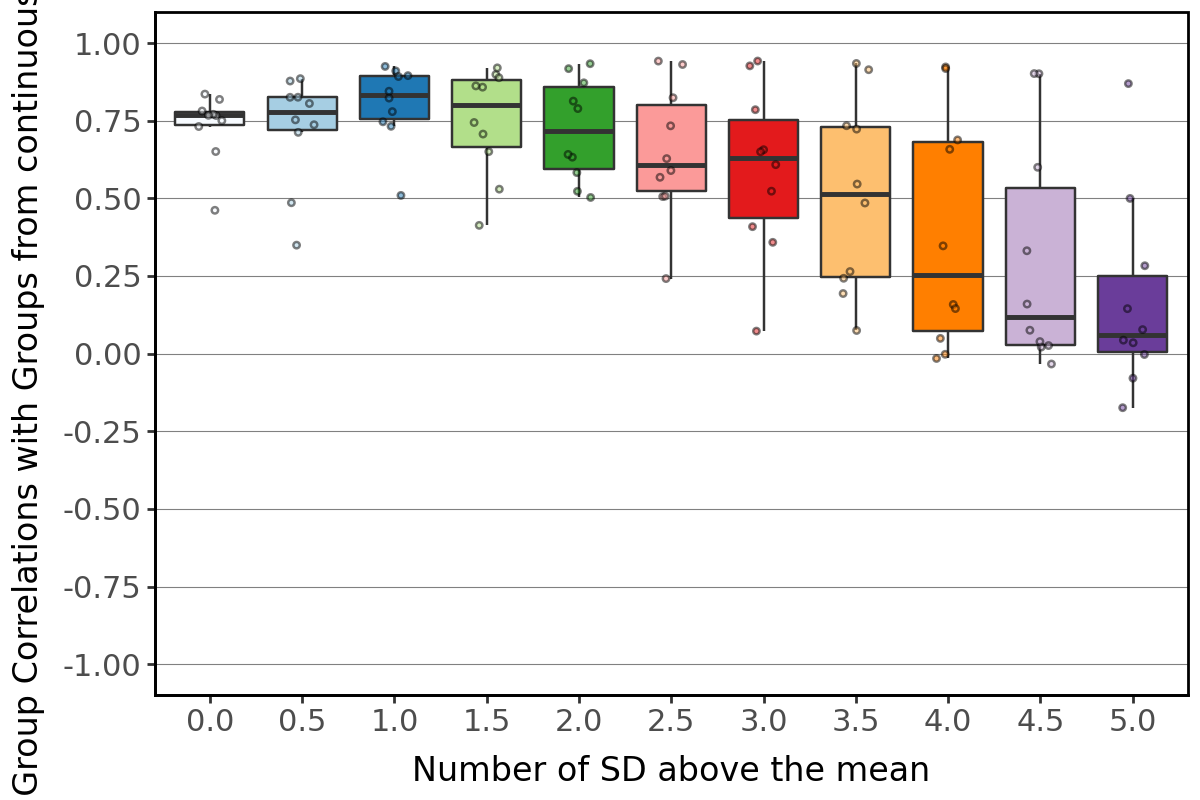

In [226]:
fig = (
ggplot(data=correlation_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Group Correlations with Groups from continuous inference')
+ theme_classic() 
+ scale_y_continuous(
        limits=(-1, 1),
        breaks=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_max_cor_n_sd_cont_box_plot_unrolled.svg'), format='svg')
fig

### Pairwise correlation (Gaussian processes = 2 and p-value/FDR < 0.05 vs continuous inference)

In [227]:
ref_value = 'cont'

In [228]:
def gmm_binarize_matrix(X, k=2, prob_threshold=0.5):
    """
    Fit a GMM per column and binarize based on component assignment.
    
    Parameters:
        X: np.array (cells x metabolites)
        k: number of Gaussian components (2)
        prob_threshold: probability threshold for assignment
    
    Returns:
        X_bin: binarized matrix
    """
    X_bin = np.zeros_like(X)

    for j in range(X.shape[1]):
        col = X[:, j].reshape(-1, 1)

        # remove NaNs
        mask = ~np.isnan(col[:, 0])
        col_valid = col[mask]

        if len(col_valid) < 10:
            continue

        gmm = GaussianMixture(n_components=k, random_state=0)
        gmm.fit(col_valid)

        # posterior probabilities
        probs = gmm.predict_proba(col_valid)

        # identify "high" component (larger mean)
        high_comp = np.argmax(gmm.means_.flatten())

        # assign
        bin_vals = (probs[:, high_comp] > prob_threshold).astype(int)

        X_bin[mask, j] = bin_vals

    return X_bin

In [229]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process='gmm'):
    
    if process not in ['gmm', 'pval', 'FDR', 'cont']:
        raise ValueError('The "process" variable needs to be one of: "gmm", "pval", "FDR", or "cont".')
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    
    if process == 'gmm':
        interacting_cell_scores_m = gmm_binarize_matrix(
            interacting_cell_scores_m,
            k=2,
            prob_threshold=0.5
        )
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        model = 'bernoulli'
    elif process in ['pval', 'FDR']:
        interacting_cell_pvalues_m = adata.uns['interacting_cell_results']['np']['m'][process]
        interacting_cell_scores_m = (interacting_cell_pvalues_m < 0.05).astype(int)
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        model = 'bernoulli'
    else:
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        std = interacting_cell_scores_m.std(axis=0)
        std_replaced = std.replace(0, 1)  # avoid division by zero
        interacting_cell_scores_m = (interacting_cell_scores_m - interacting_cell_scores_m.mean(axis=0)) / std_replaced
        model = 'none'
        
    metab_scores_adata = ad.AnnData(interacting_cell_scores_m)
    metab_scores_adata.obs_names = adata.obs_names
    metab_scores_adata.var_names = adata.uns['metabolites']

    metab_scores_adata.obs['cond'] = adata.obs['cond']
    metab_scores_adata.obsm['spatial_unrolled'] = adata.obsm['spatial_unrolled']
    metab_scores_adata.obsm['spatial'] = adata.obsm['spatial']
    
    harreman.tl.compute_knn_graph(metab_scores_adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.hs.compute_local_autocorrelation(metab_scores_adata, model=model)
    
    gene_autocorrelation_results = metab_scores_adata.uns['gene_autocorrelation_results']
    metabolites = gene_autocorrelation_results.index
    
    harreman.hs.compute_local_correlation(metab_scores_adata, genes=metabolites)
        
    harreman.hs.create_modules(metab_scores_adata, min_gene_threshold=9)
    
    harreman.hs.calculate_module_scores(metab_scores_adata)
    
    return metab_scores_adata.uns['gene_modules'], metab_scores_adata.obsm['module_scores']

In [230]:
def pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref):
    
    jaccard_sim_matrix = np.zeros((len(gene_modules.keys()), len(gene_modules_ref.keys())))
    for i in range(len(gene_modules.keys())):
        for j in range(len(gene_modules_ref.keys())):
            key_i = list(gene_modules.keys())[i]
            key_j = list(gene_modules_ref.keys())[j]
            a = gene_modules[key_i]
            b = gene_modules_ref[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=gene_modules.keys(), columns=gene_modules_ref.keys())
    
    correlation_matrix = pd.DataFrame(
        [[module_scores[col1].corr(module_scores_ref[col2]) for col2 in module_scores_ref.columns] for col1 in module_scores.columns],
        index=module_scores.columns,
        columns=module_scores_ref.columns
    )
    
    similarity_matrix = (jaccard_sim_matrix_df + correlation_matrix)/2
    max_similarity = similarity_matrix.idxmax()
    
    correlation_values = [correlation_matrix.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    jaccard_values = [jaccard_sim_matrix_df.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    
    return correlation_values, jaccard_values

In [231]:
pairwise_correlation_gene_modules_dict = {}
pairwise_correlation_module_scores_dict = {}
for process in ['gmm', 'pval', 'FDR', 'cont']:
    print(process)
    gene_modules, module_scores = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process)
    pairwise_correlation_gene_modules_dict[process] = gene_modules
    pairwise_correlation_module_scores_dict[process] = module_scores

gmm


100%|██████████| 9/9 [00:00<00:00, 17.96it/s]


pval


100%|██████████| 10/10 [00:00<00:00, 20.71it/s]


FDR


100%|██████████| 8/8 [00:00<00:00, 19.94it/s]


cont


100%|██████████| 10/10 [00:00<00:00, 26.87it/s]


In [232]:
correlation_values_dict = {}
jaccard_values_dict = {}
n_modules_dict = {}
for process in ['gmm', 'pval', 'FDR']:
    gene_modules = pairwise_correlation_gene_modules_dict[process]
    module_scores = pairwise_correlation_module_scores_dict[process]
    gene_modules_ref = pairwise_correlation_gene_modules_dict[ref_value]
    module_scores_ref = pairwise_correlation_module_scores_dict[ref_value]
    correlation_values, jaccard_values = pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref)
    correlation_values_dict[process] = correlation_values
    jaccard_values_dict[process] = jaccard_values
    n_modules_dict[process] = len(gene_modules.keys())

In [233]:
n_modules_df = pd.DataFrame.from_dict(n_modules_dict.items()).rename(columns={0: 'process', 1: 'n_modules'})

In [234]:
jaccard_values_df = pd.concat(
    {key: pd.Series(list) for key, list in jaccard_values_dict.items()}, axis=1
).melt( 
    var_name="process", 
    value_name="Value"
)

correlation_values_df = pd.concat(
    {key: pd.Series(list) for key, list in correlation_values_dict.items()}, axis=1
).melt( 
    var_name="process", 
    value_name="Value"
)

In [235]:
jaccard_values_df["process"] = jaccard_values_df["process"].astype('category')
jaccard_values_df["process"] = jaccard_values_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])
correlation_values_df["process"] = correlation_values_df["process"].astype('category')
correlation_values_df["process"] = correlation_values_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])
n_modules_df["process"] = n_modules_df["process"].astype('category')
n_modules_df["process"] = n_modules_df["process"].cat.reorder_categories(['gmm', 'pval', 'FDR'])

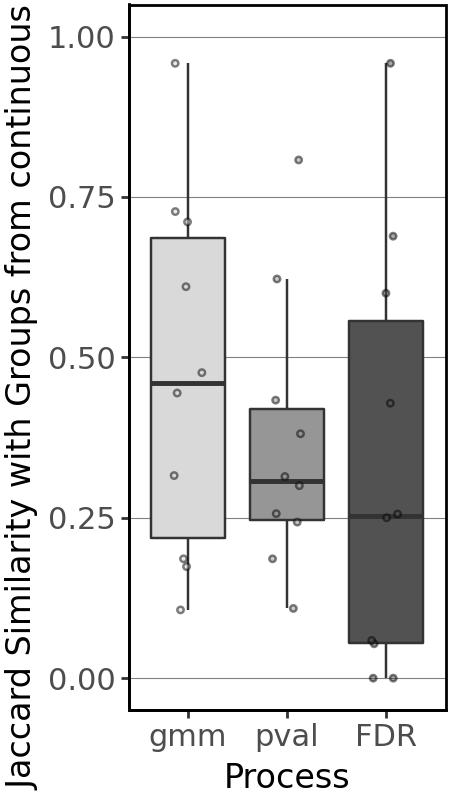

In [236]:
fig = (
ggplot(data=jaccard_values_df, mapping=aes(x="process", y="Value", fill="process")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#D9D9D9", "#969696", "#525252"])
+ xlab('Process')
+ ylab('Max. Jaccard Similarity with Groups from continuous inference')
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(2.25, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_jaccard_processes_cont_box_plot_unrolled.svg'), format='svg')
fig

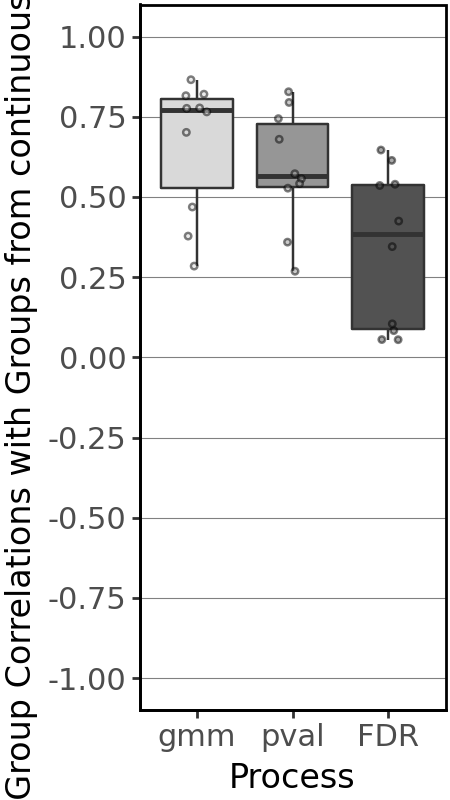

In [237]:
fig = (
ggplot(data=correlation_values_df, mapping=aes(x="process", y="Value", fill="process")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#D9D9D9", "#969696", "#525252"])
+ xlab('Process')
+ ylab('Max. Group Correlations with Groups from continuous inference')
+ theme_classic() 
+ scale_y_continuous(
        limits=(-1, 1),
        breaks=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(2.25, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_max_cor_processes_cont_box_plot_unrolled.svg'), format='svg')
fig

### Jaccard similarities

In [137]:
threshold_values = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
processes = ['gmm', 'pval', 'FDR']

In [138]:
def compute_jaccard_matrix_per_metabolite(dict_of_dfs):

    methods = list(dict_of_dfs.keys())

    # --- ensure all dataframes aligned ---
    # intersection of spots and metabolites
    common_spots = set.intersection(*[set(df.index) for df in dict_of_dfs.values()])
    common_metabs = set.intersection(*[set(df.columns) for df in dict_of_dfs.values()])

    # sort for consistency
    common_spots = sorted(common_spots)
    common_metabs = sorted(common_metabs)

    # subset all dfs
    dict_of_dfs = {
        k: df.loc[common_spots, common_metabs].astype(bool)
        for k, df in dict_of_dfs.items()
    }

    # --- compute pairwise jaccard ---
    results = {}

    for m1, m2 in product(methods, methods):

        df1 = dict_of_dfs[m1]
        df2 = dict_of_dfs[m2]

        jaccards = []

        for metab in common_metabs:
            a = df1[metab]
            b = df2[metab]

            intersection = np.logical_and(a, b).sum()
            union = np.logical_or(a, b).sum()

            if union == 0:
                j = np.nan  # or 1.0 depending on preference
            else:
                j = intersection / union

            jaccards.append(j)

        results[f"{m1}|{m2}"] = jaccards

    jaccard_df = pd.DataFrame(results, index=common_metabs).T

    return jaccard_df

In [139]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process):
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    
    if process == 'gmm':
        interacting_cell_scores_m = gmm_binarize_matrix(
            interacting_cell_scores_m,
            k=2,
            prob_threshold=0.5
        )
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    elif process in ['pval', 'FDR']:
        interacting_cell_pvalues_m = adata.uns['interacting_cell_results']['np']['m'][process]
        interacting_cell_scores_m = (interacting_cell_pvalues_m < 0.05).astype(int)
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    else:
        means = np.nanmean(interacting_cell_scores_m, axis=0)
        stds = np.nanstd(interacting_cell_scores_m, axis=0)
        thresholds = means + process*stds
        interacting_cell_scores_m[interacting_cell_scores_m < thresholds] = 0
        
        interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
        interacting_cell_scores_m[interacting_cell_scores_m != 0] = 1
    
    return interacting_cell_scores_m

In [140]:
binary_df_dict = {}
for process in threshold_values+processes:
    print(process)
    binary_df = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, process)
    key = f"sd_{str(process)}" if not isinstance(process, str) else process
    binary_df_dict[key] = binary_df

0
0.5
1
1.5
2
2.5
3
3.5
4
4.5
5
gmm
pval
FDR


In [141]:
jaccard_df = compute_jaccard_matrix_per_metabolite(binary_df_dict)

In [142]:
jaccard_long = (
    jaccard_df
    .reset_index()
    .rename(columns={"index": "method_pair"})
    .melt(id_vars="method_pair", var_name="metabolite", value_name="jaccard")
)

sd_1


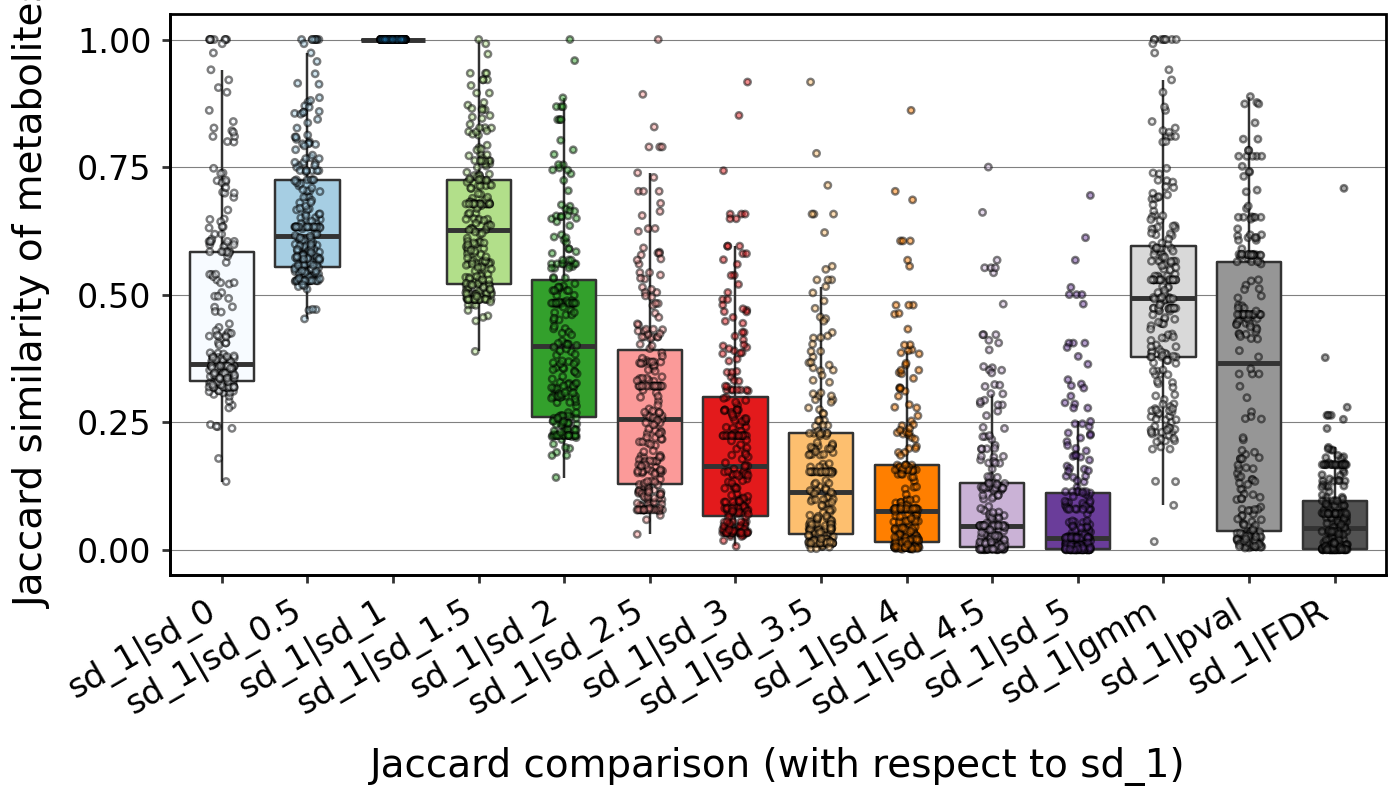

gmm


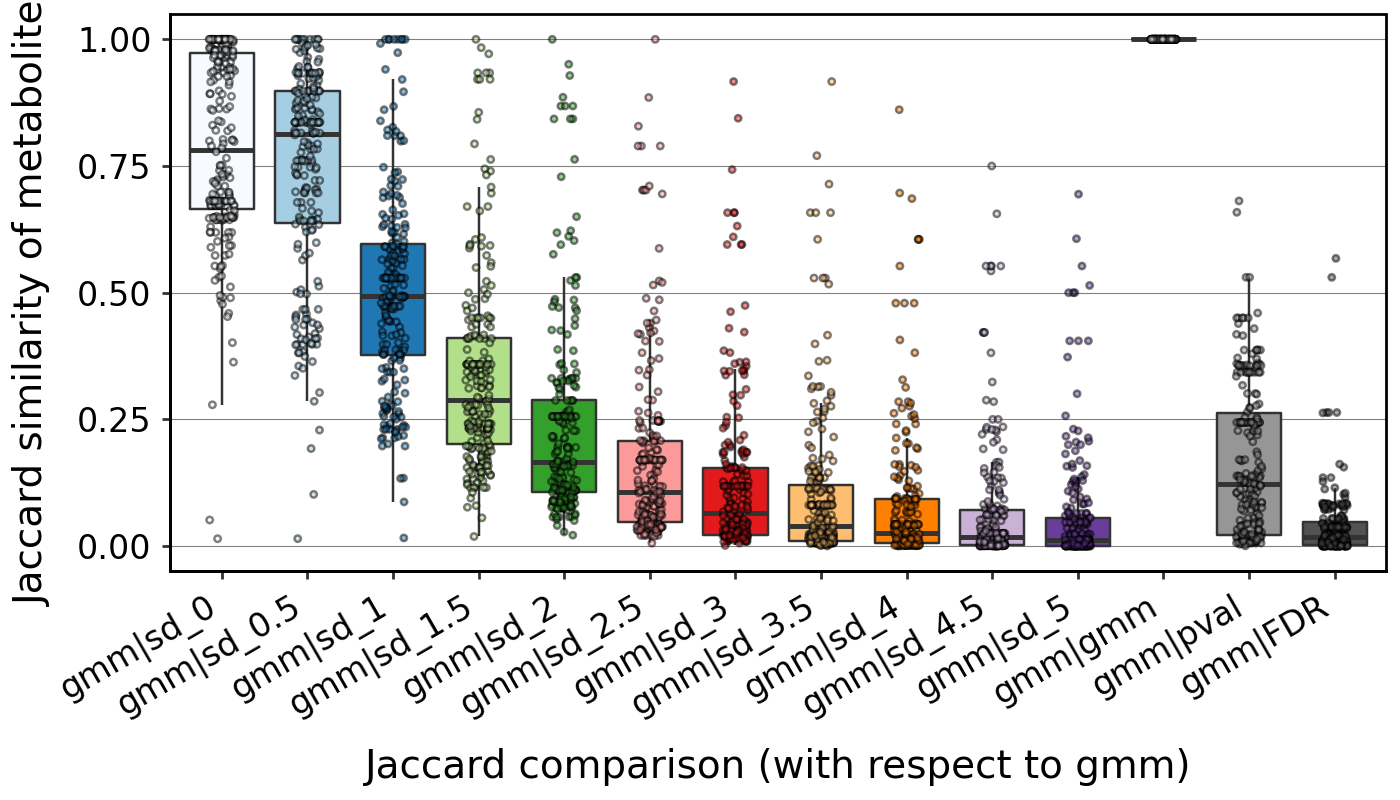

pval


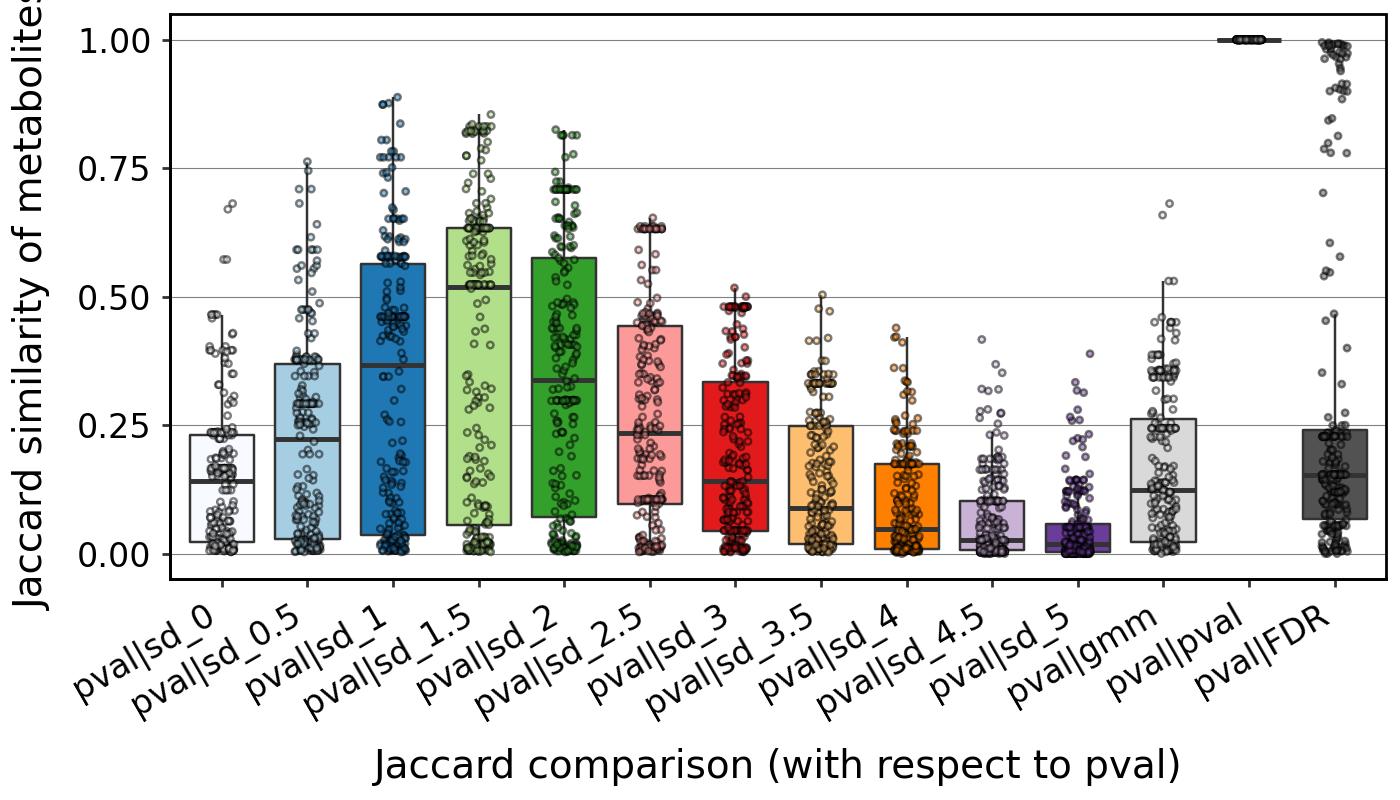

FDR


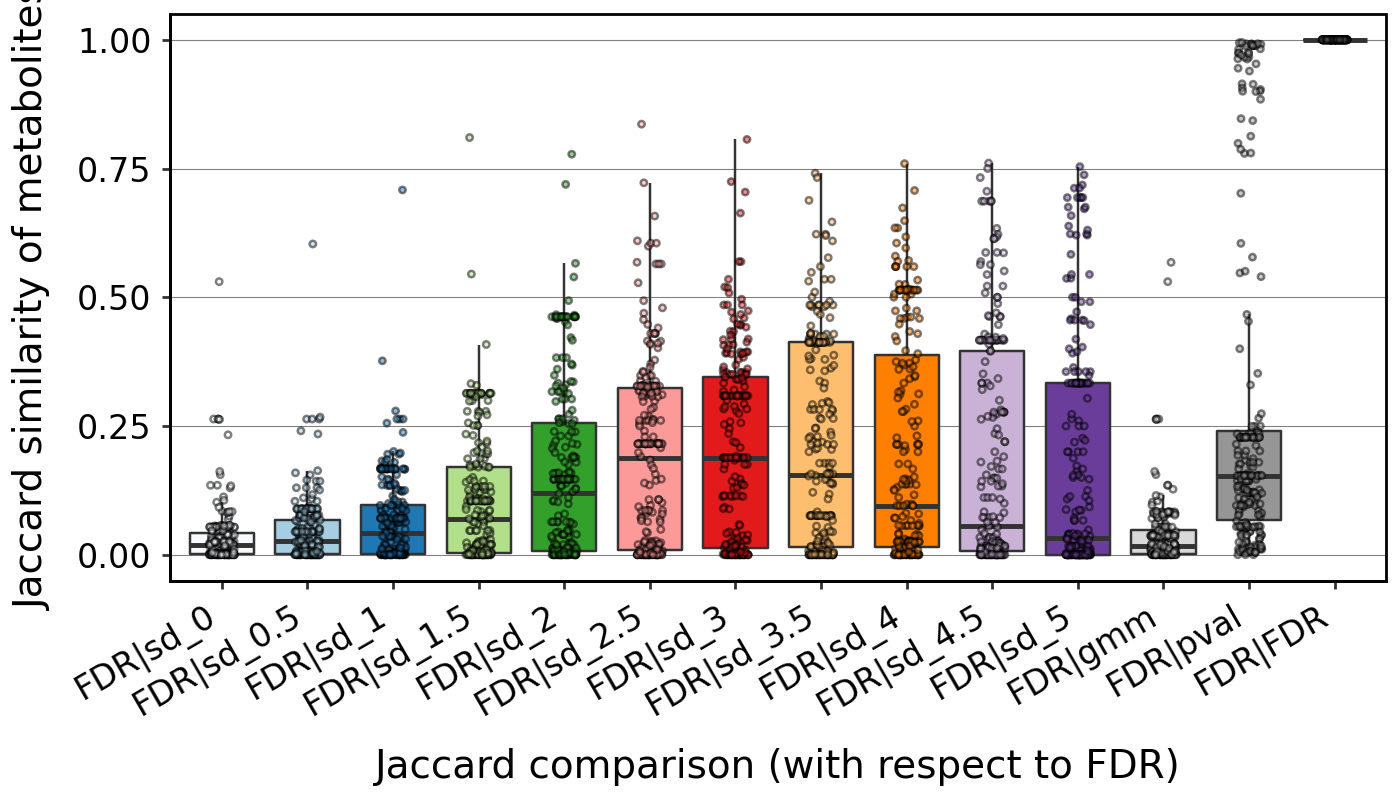

In [145]:
vars_of_interest = ['sd_1', 'gmm', 'pval', 'FDR']
for val in vars_of_interest:
    print(val)
    val_comps = [comp for comp in jaccard_df.index if f'{val}|' in comp]
    jaccard_long_val_comps = jaccard_long[jaccard_long['method_pair'].isin(val_comps)].copy()
    jaccard_long_val_comps['method_pair'] = jaccard_long_val_comps['method_pair'].astype('category')
    jaccard_long_val_comps['method_pair'] = jaccard_long_val_comps['method_pair'].cat.reorder_categories(val_comps)
    
    fig = (
    ggplot(data=jaccard_long_val_comps, mapping=aes(x='method_pair', y='jaccard', fill='method_pair')) 
    + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
    + geom_jitter(width=0.15, height=0, size=0.8, alpha=0.5)
    + scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A", "#D9D9D9", "#969696", "#525252"])
    + xlab(f'Jaccard comparison (with respect to {val})')
    + ylab('Jaccard similarity of metabolites')
    + theme_classic() 
    + scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
    )
    + theme(panel_grid_major_y=element_line(color="grey", size=0.4),
            panel_grid_minor_y=element_blank(),
            plot_title = element_text(hjust = 0.5,
                                    margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                    size = 14,
                                    face='bold'),
            legend_position = "none",
            axis_title_x = element_text(size = 14),
            axis_title_y = element_text(size = 14),
            axis_text_x = element_text(margin={"t": 4, "b": 4, "l": 0, "r": 0}, size = 12, colour='black', rotation=30, hjust=1),
            axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 4, "r": 4}, size = 12, colour='black'),
            panel_border = element_rect(color='black'),
            panel_background = element_rect(colour = "black",
                                            linewidth = 1),
            figure_size=(7, 4))
    )
    fig.show()
    fig.save(os.path.join(PLOTS_PATH, f'{val}_metab_jaccard_comp_box_plot.pdf'), format='pdf')